# Lab 2: Predictive Analytics with Machine Learning
## Part 0: Setup

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

## Section 1 — Supervised Learning: Regression

Shape: (41202, 13)

Head:
   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0          6.94                

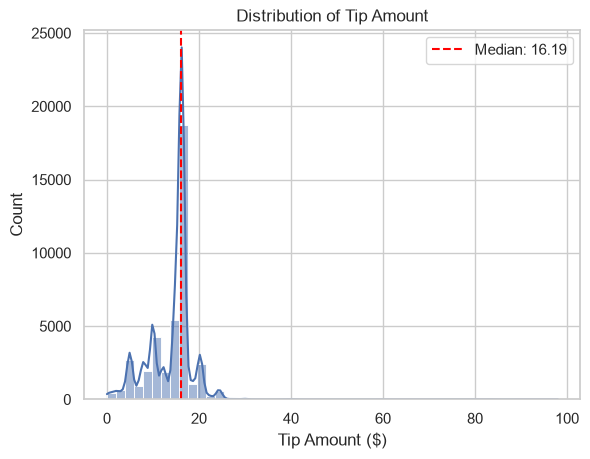

In [8]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
print("Shape:", taxi.shape)
print("\nHead:")
print(taxi.head())
print("\nInfo:")
taxi.info()
# - taxi.describe()
print("\nDescribe:")
print(taxi.describe())
# - count missing values per column: taxi.isna().sum()
print("\nMissing values per column:")
print(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
print("\nTip amount quantiles:")
print(taxi["tip_amount"].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Max tip amount:", taxi["tip_amount"].max())

sns.histplot(taxi["tip_amount"], kde=True, bins=50)
plt.title("Distribution of Tip Amount")
plt.xlabel("Tip Amount ($)")
plt.ylabel("Count")
plt.axvline(taxi["tip_amount"].median(), color="red", linestyle="--", label=f"Median: {taxi['tip_amount'].median():.2f}")
plt.legend()
plt.show()

## Part 1.2 — Preprocessing & feature engineering